# IAT 461 / 882 Final Project: FitnessPlanet Member Retention Strategy

**Name:** `Derek Cheng`
**SFU ID:** `dca130`
**Date:** `August 4th 2026`
**Client:** FitnessPlanet (mid size gym chain)
**Dataset:** `data/gym_ghosts_master.csv`, 50,000 member records across 24 columns

## Overview: the two problems in my own words

FitnessPlanet gets a January flood of new members and then loses almost half of them by the end of February. Leadership has three ideas on the table and wants to know which one to fund before the next January.

**Problem 1 (Phase 1): which of the three options does the data actually support?**

In my words: leadership has three theories about why members ghost. Option A says the fix is class attendance, Option B says the fix is visit frequency, Option C says the fix is price. My job is not to pick the option with the biggest correlation. It is to work out which of the three is a lever leadership can actually pull, and to show with evidence why the other two are weaker than they look. The interesting part is that all three ideas will look supported if I only run correlations, because class attendance and visit frequency both separate churners from stayers very strongly. So the work is in separating a real cause from a symptom.

**Problem 2 (Phase 2): assuming leadership goes with Option C, how much does the fee alone actually drive churn?**

In my words: build a model that predicts `churned_by_february` from the monthly fee plus the other things we know about a member in their first month, then pull the fee effect out of that model on its own so leadership can answer one specific question, which is whether adjusting the price is worth it. That means I need two things from the model. A prediction number so we know the model is worth trusting, and a clean fee coefficient that is not contaminated by the fact that expensive plans and cheap plans are different kinds of contract.

The client sharpened this at the check in. The target to optimise is **not** churn on its own, it is **retained revenue**, meaning fee multiplied by the probability the member stays, evaluated inside the fee range that already exists in the data. That is a better objective than minimising churn, because churn goes to zero if you give memberships away. So Phase 2 ends in a single recommended rate, not a churn number.

**What success looks like for the client:** their stated criteria is an EDA section that shows why two of the options are not as strong, then a clear answer on whether pricing is worth adjusting that is specific enough to act on. So the deliverable has to end in a number and a recommendation, not a list of correlations.

## The client's answers, and what each one changed

| # | What I asked | What the client said | What it changed |
| --- | --- | --- | --- |
| 1 | Does `churned_by_february` mean cancelled, stopped attending, or both? | **Both, pooled.** The system does not separate them and no other field exists. To be carried as a limitation | Changes how I read the EDA. If "stopped attending" is inside the label then class attendance and visit frequency are partly scored against their own definition, so the correlations in 2.5 and the separation in 2.6 are upper bounds rather than estimates |
| 2 | What does minimising churn mean, and what are its limits? | Optimise **retained revenue**, fee multiplied by stay probability, **within the fee range present in the data**, rather than pure churn | Sets the objective for Problem 2. Not churn on its own, which is degenerate, but an optimisation with one output number. Written into the direction in 3.2 |
| 3 | Fee varies with contract type and promotion, should I account for it? | **Necessary.** They explicitly want to avoid concluding that "lower price works" when it really means annual members are more committed | Sent me back into the EDA. Section 2.7 exists because of this answer, and it shows they were right: contract type does confound the fee, promotion does not |
| 4 | One overall rate, or segmented? | **One overall value.** Segmented results belong in an appendix. **No segmentation by age or gender** | Problem 2 has to end in a single rate with any segmented cut kept to an appendix. Nothing in this notebook is broken out by age or sex, and both stay as model controls only |
| 5 | What kind of model? | Up to me, but management has to be able to follow it | Confirms logistic regression over the tree ensembles, decided on legibility rather than accuracy. Reasoning in 3.2 |

## Setup

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve,
)

warnings.filterwarnings("ignore")

# plotting style (same palette as my earlier assignments)
ACCENT = "#e8925a"
DARK = "#1e3a5f"
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

ROOT = Path(".").resolve()
DATA_PATH = ROOT / "data" / "gym_ghosts_master.csv"
DICT_PATH = ROOT / "data" / "data_dictionary.csv"

RANDOM_STATE = 42
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

print("Ready. Data path:", DATA_PATH, "| exists:", DATA_PATH.exists())

Ready. Data path: /Users/hytherist/Documents/GitHub/IAT461-Final-Assignment/data/gym_ghosts_master.csv | exists: True


## 1: Data loading and documentation

### 1.1: Load and inspect

In [2]:
raw = pd.read_csv(DATA_PATH)
data_dict = pd.read_csv(DICT_PATH)

print(f"Shape: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
print(f"\nMemory: {raw.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"\nColumn types:\n{raw.dtypes.value_counts()}")
raw.head(3)

Shape: 50,000 rows x 24 columns

Memory: 19.4 MB

Column types:
int64      18
object      4
float64     2
Name: count, dtype: int64


,member_id,age,sex,distance_km,prior_gym_experience,joined_with_friend,contract_type,monthly_fee_usd,signup_week_january,promo_used,primary_goal,goal_aggressiveness,week1_visits,week2_visits,week3_visits,week4_visits,avg_weekly_classes,booked_induction,personal_trainer,app_installed,avg_session_minutes,guest_passes_used,locker_rented,churned_by_february
0,GYM000000,40,F,6.6,1,0,6_month,47.07,1,0,general_health,3,3,2,1,1,1,0,0,0,42,1,0,1
1,GYM000001,55,F,3.8,0,0,month_to_month,62.59,4,1,weight_loss,1,2,3,2,2,1,0,0,0,62,0,0,1
2,GYM000002,26,F,3.9,0,0,annual,36.68,2,1,muscle_gain,5,1,0,2,0,0,1,0,0,17,1,1,1


In [3]:
# The Kaggle download ships a data dictionary alongside the CSV, so I use theirs
# rather than retyping the client proposal.
data_dict

,column,type,description
0,member_id,string,Unique member id
1,age,int,Member age in years
2,sex,string,F / M / Other
3,distance_km,float,Distance from home to gym (km); nearer = stickier
4,prior_gym_experience,int,"1 if had a gym membership before, else 0"
5,joined_with_friend,int,1 if referred/joined with a friend (accountabi...
6,contract_type,string,month_to_month / 6_month / annual
7,monthly_fee_usd,float,Monthly membership fee (USD)
8,signup_week_january,int,Week of January they signed up (1-4)
9,promo_used,int,1 if joined via a New-Year promo


### 1.2: Column dictionary

Source: `gym_ghosts_master.csv` from the Kaggle dataset linked in the client proposal
(`sergionefedov/gym-will-your-new-years-resolution-survive`), shipped with its own `data_dictionary.csv`.
Every column below is one row per member, one member per row.

| Column | Type | Meaning | When it is known |
| --- | --- | --- | --- |
| `member_id` | string | Unique member id, format `GYM######` | signup |
| `age` | int | Age in years | signup |
| `sex` | string | F / M / Other | signup |
| `distance_km` | float | Home to gym distance in km | signup |
| `prior_gym_experience` | int | 1 if they had a membership before | signup |
| `joined_with_friend` | int | 1 if referred or joined with someone | signup |
| `contract_type` | string | month_to_month / 6_month / annual | signup |
| `monthly_fee_usd` | float | Monthly membership fee | signup |
| `signup_week_january` | int | Week of January they signed up, 1 to 4 | signup |
| `promo_used` | int | 1 if they came in on the New Year promo | signup |
| `primary_goal` | string | weight_loss / muscle_gain / general_health / event_prep | signup |
| `goal_aggressiveness` | int | 1 realistic to 5 unrealistic | signup |
| `booked_induction` | int | 1 if they booked an intro session | first month |
| `week1_visits` ... `week4_visits` | int | Visits in each of the first four weeks | first month |
| `avg_weekly_classes` | int | Average group classes per week | first month |
| `personal_trainer` | int | 1 if using a PT | first month |
| `app_installed` | int | 1 if the gym app is installed | first month |
| `avg_session_minutes` | int | Average session length | first month |
| `guest_passes_used` | int | Guest passes used | first month |
| `locker_rented` | int | 1 if renting a locker | first month |
| `churned_by_february` | int | **Target.** 1 if ghosted or cancelled by end of February | outcome |

The "when it is known" column is the one that matters most for this project and it is not in the client
proposal, I added it. Twelve fields are fixed at signup and the gym knows them on day one. Nine are
behaviours recorded during the same window in which the member either stays or ghosts. The target is
measured at the end of that same window. Phase 1 lives or dies on that distinction, so I set it up here
before touching the analysis.

### 1.3: Data quality audit

In [4]:
# Week 3 order of operations: sniff test first, then decide, do not delete anything yet.
# reference: Week 3 slides, "The Sniff Test" and "Missing Values"
print("Missing values per column:")
miss = raw.isna().sum()
print(miss[miss > 0] if miss.sum() else "  none, zero missing across all 24 columns")

print(f"\nDuplicate member_id: {raw['member_id'].duplicated().sum()}")
print(f"Fully duplicated rows: {raw.duplicated().sum()}")
print(f"member_id format check (GYM + 6 digits): "f"{raw['member_id'].str.fullmatch(r'GYM\d{6}').all()}")

print("\nNumeric ranges:")
print(raw.describe().T[["min", "max", "mean", "50%", "std"]].round(2))

print("\nCategorical levels:")
for c in ["sex", "contract_type", "primary_goal"]:
    vc = raw[c].value_counts()
    print(f"  {c}: {dict(vc)}")

print("\nBinary flags, checking nothing outside 0/1:")
flags = ["prior_gym_experience", "joined_with_friend", "promo_used", "booked_induction",
         "personal_trainer", "app_installed", "locker_rented", "churned_by_february"]
print("  ", {c: sorted(raw[c].unique()) for c in flags})

Missing values per column:
  none, zero missing across all 24 columns

Duplicate member_id: 0
Fully duplicated rows: 0
member_id format check (GYM + 6 digits): True

Numeric ranges:
                       min     max   mean    50%    std
age                   16.0   71.00  32.23  32.00   9.49
distance_km            0.1   40.00   6.02   5.00   4.28
prior_gym_experience   0.0    1.00   0.45   0.00   0.50
joined_with_friend     0.0    1.00   0.28   0.00   0.45
monthly_fee_usd       15.0  101.89  53.90  53.74  11.75
signup_week_january    1.0    4.00   1.99   2.00   1.04
promo_used             0.0    1.00   0.55   1.00   0.50
goal_aggressiveness    1.0    5.00   3.00   3.00   1.42
week1_visits           0.0   14.00   2.81   2.00   2.35
week2_visits           0.0   14.00   2.39   2.00   2.09
week3_visits           0.0   14.00   1.97   2.00   1.83
week4_visits           0.0   14.00   1.63   1.00   1.60
avg_weekly_classes     0.0   12.00   1.58   1.00   1.55
booked_induction       0.0    1.00

In [5]:
# Outlier audit, both methods from Week 3, applied to the continuous columns.
# reference: Week 3 slides, "IQR - Interquartile Range" and "Z-Score"
cont = ["age", "distance_km", "monthly_fee_usd", "avg_session_minutes",
        "week1_visits", "week2_visits", "week3_visits", "week4_visits", "avg_weekly_classes"]

rows = []
for c in cont:
    s = raw[c]
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    z = (s - s.mean()) / s.std()
    rows.append({
        "column": c,
        "min": s.min(), "max": s.max(),
        "iqr_low": round(lo, 2), "iqr_high": round(hi, 2),
        "n_iqr_out": int(((s < lo) | (s > hi)).sum()),
        "n_z_gt3": int((z.abs() > 3).sum()),
        "skew": round(s.skew(), 2),
    })
pd.DataFrame(rows)

,column,min,max,iqr_low,iqr_high,n_iqr_out,n_z_gt3,skew
0,age,16.0,71.00,4.00,60.00,105,105,0.25
1,distance_km,0.1,40.00,-4.90,15.90,1678,715,1.42
2,monthly_fee_usd,15.0,101.89,21.51,86.02,242,113,0.11
3,avg_session_minutes,10.0,115.00,4.00,92.00,169,77,0.07
4,week1_visits,0.0,14.00,-3.50,8.50,1419,899,1.37
5,week2_visits,0.0,14.00,-2.00,6.00,2319,780,1.41
6,week3_visits,0.0,14.00,-2.00,6.00,1257,702,1.49
7,week4_visits,0.0,14.00,-3.00,5.00,1345,657,1.46
8,avg_weekly_classes,0.0,12.00,-3.00,5.00,1197,554,1.42


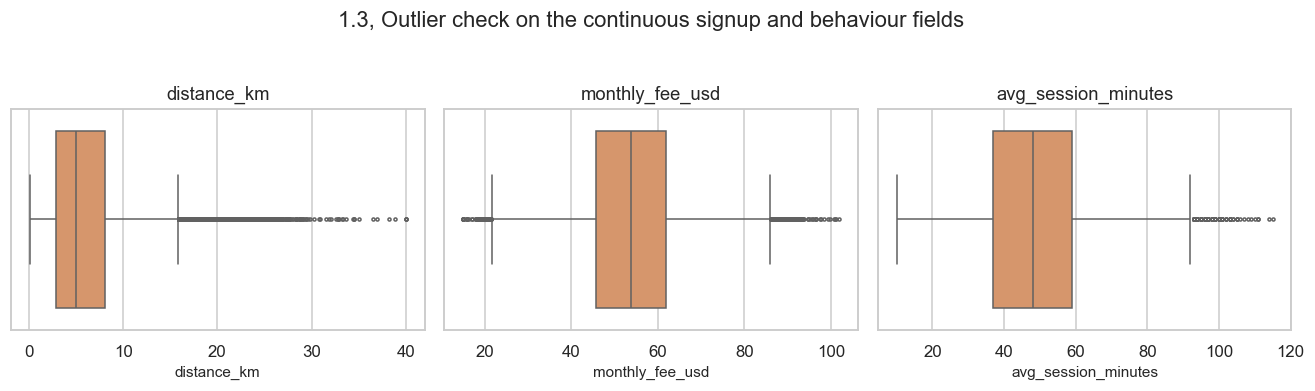

In [6]:
# Boxplots for the three continuous fields the client cares about
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for ax, c in zip(axes, ["distance_km", "monthly_fee_usd", "avg_session_minutes"]):
    sns.boxplot(x=raw[c], ax=ax, color=ACCENT, fliersize=2)
    ax.set_title(c)
fig.suptitle("1.3, Outlier check on the continuous signup and behaviour fields", y=1.04)
plt.tight_layout()
plt.show()

**Observations**

- No missing values, no duplicate ids, no duplicate rows
- IQR flags 1,678 on `distance_km`, 242 on `monthly_fee_usd`, 1,200 to 2,300 on each visit column. Z score above 3 flags fewer since those columns are right skewed
- These are artifacts not errors (Week 3). A 40 km commute, a $101.89 premium plan and 14 visits in a week are all possible, and nothing is negative or impossible
- Keeping all 50,000 rows. Dropping the distance tail cuts the members the question is about, dropping the visit tail flattens what A and B rest on

## 2: Exploratory data analysis

### 2.1: The target

Churned by February: 22,560 of 50,000 members (45.12%)
Stayed: 27,440 (54.88%)


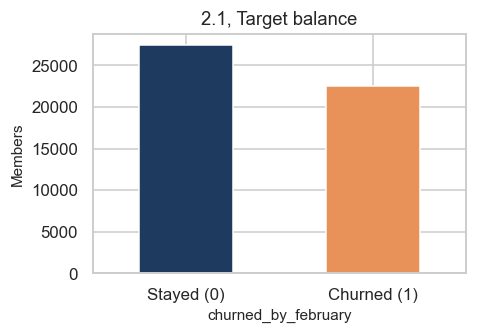

In [7]:
churn_rate = raw["churned_by_february"].mean()
n_churn = int(raw["churned_by_february"].sum())
print(f"Churned by February: {n_churn:,} of {len(raw):,} members ({churn_rate*100:.2f}%)")
print(f"Stayed: {len(raw)-n_churn:,} ({(1-churn_rate)*100:.2f}%)")

fig, ax = plt.subplots(figsize=(4.5, 3.2))
raw["churned_by_february"].value_counts().sort_index().plot(kind="bar", ax=ax, color=[DARK, ACCENT], rot=0)
ax.set_xticklabels(["Stayed (0)", "Churned (1)"])
ax.set_ylabel("Members")
ax.set_title("2.1, Target balance")
plt.tight_layout()
plt.show()

**Observations**

- 22,560 of 50,000 ghosted, so churn is 45.12%. Matches the "nearly half" in the proposal
- Nearly balanced at 45 / 55, so accuracy is readable here unlike Assignment 2. Baseline is 54.88%
- Still reporting precision, recall, F1 and AUC since the two error types dont cost the same (Week 4)

### 2.2: Feature distributions

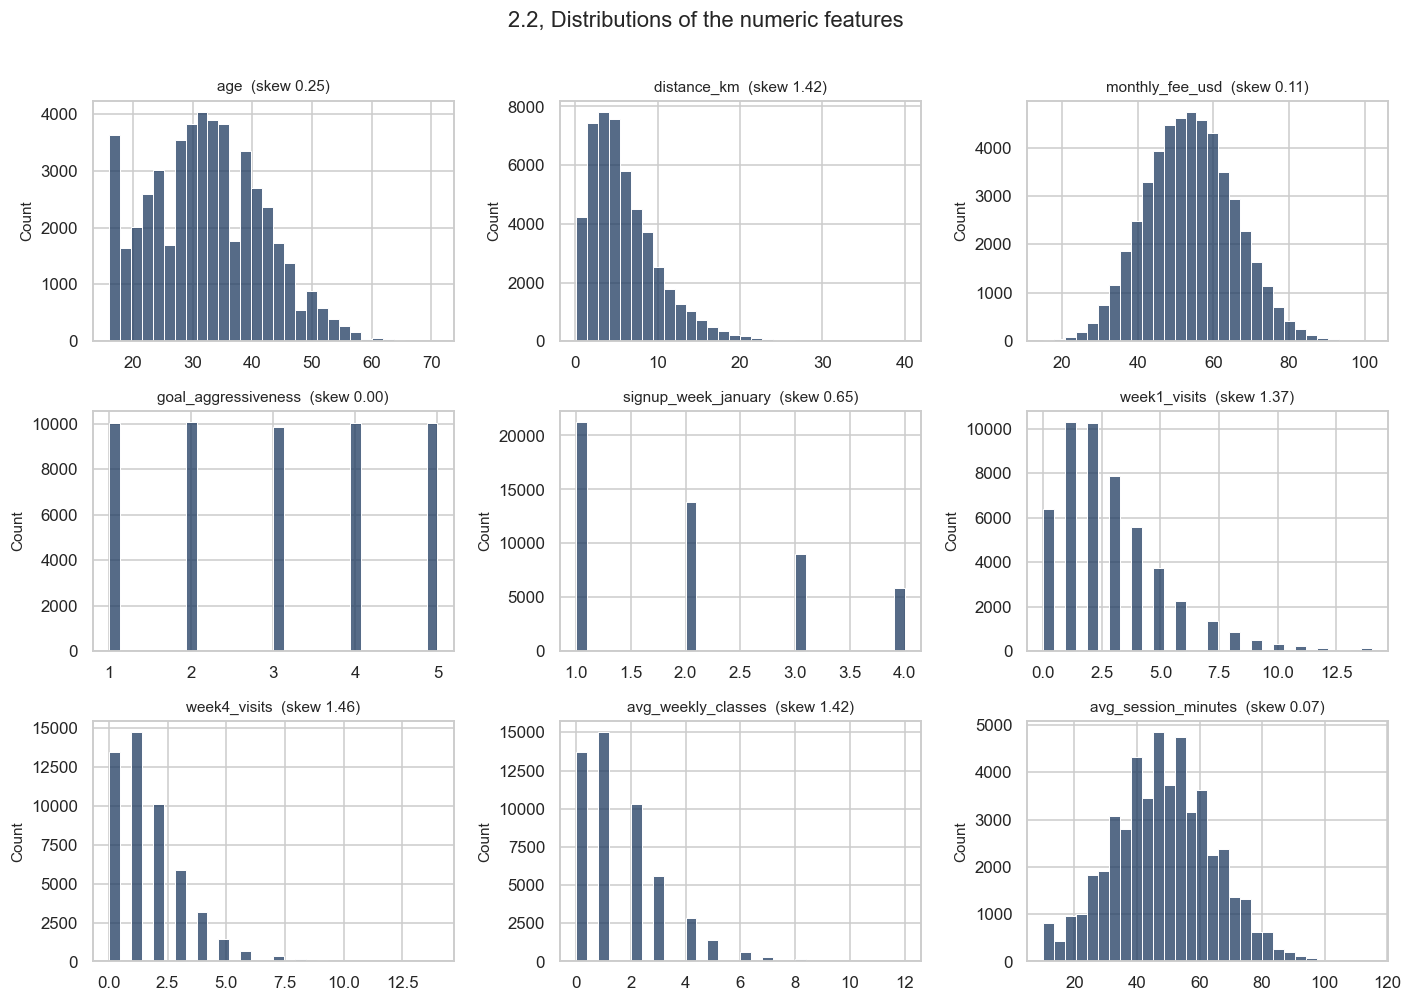

In [8]:
num_cols = ["age", "distance_km", "monthly_fee_usd", "goal_aggressiveness", "signup_week_january",
            "week1_visits", "week4_visits", "avg_weekly_classes", "avg_session_minutes"]

fig, axes = plt.subplots(3, 3, figsize=(13, 9))
for ax, c in zip(axes.ravel(), num_cols):
    sns.histplot(raw[c], bins=30, ax=ax, color=DARK)
    ax.set_title(f"{c}  (skew {raw[c].skew():.2f})", fontsize=10)
    ax.set_xlabel("")
fig.suptitle("2.2, Distributions of the numeric features", y=1.01)
plt.tight_layout()
plt.show()

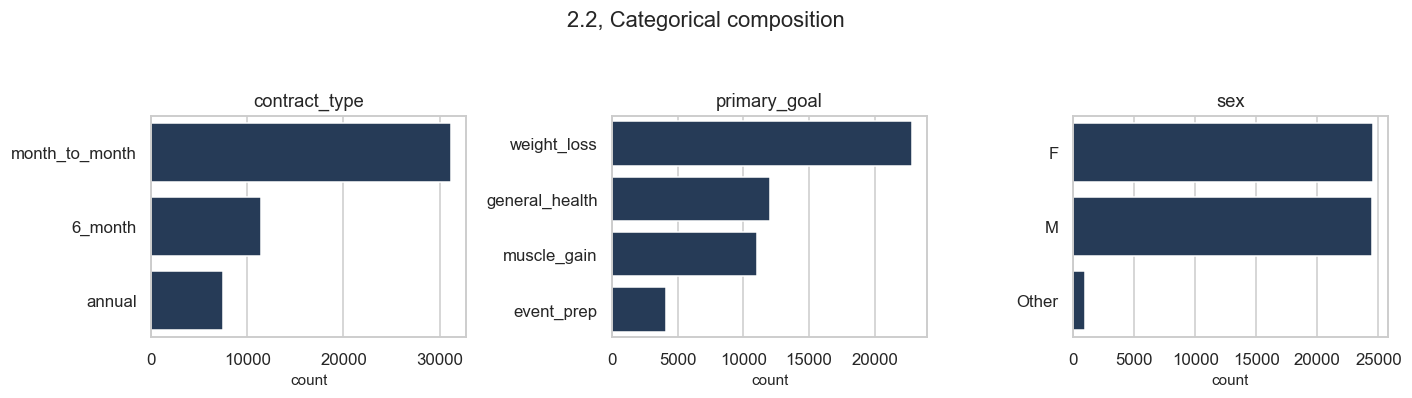


contract_type:
contract_type
month_to_month    62.4%
6_month           22.7%
annual            14.8%
Name: proportion, dtype: object

primary_goal:
primary_goal
weight_loss       45.7%
general_health    24.1%
muscle_gain       22.0%
event_prep         8.2%
Name: proportion, dtype: object

signup_week_january:
signup_week_january
1    42.5%
2    27.7%
3    18.1%
4    11.8%
Name: proportion, dtype: object


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, c in zip(axes, ["contract_type", "primary_goal", "sex"]):
    order = raw[c].value_counts().index
    sns.countplot(y=raw[c], order=order, ax=ax, color=DARK)
    ax.set_title(c)
    ax.set_ylabel("")
fig.suptitle("2.2, Categorical composition", y=1.06)
plt.tight_layout()
plt.show()

for c in ["contract_type", "primary_goal", "signup_week_january"]:
    print(f"\n{c}:")
    print((raw[c].value_counts(normalize=True) * 100).round(1).astype(str) + "%")

**Observations**

- Age mildly right skewed (0.25) centred at 32, distance skewed 1.42 with median 5.0 km and a tail to 40, fee near symmetric (0.11) around $53.90
- `goal_aggressiveness` is dead flat, about 10,000 per level
- Signups front loaded, 42.5% in week 1 then 27.7%, 18.1%, 11.8%
- Contract mix 62.4% month_to_month, 22.7% 6_month, 14.8% annual. Biggest thing in here, and it is what the Phase 2 fee work has to control for
- Behaviour columns are the skewed ones. `avg_weekly_classes` skewed 1.42 with 13,684 (27.4%) at zero, already a problem for Option A

### 2.3: Missingness and the visit decay curve

Mean visits per week, stayers vs churners:
                     week1_visits  week2_visits  week3_visits  week4_visits
churned_by_february                                                        
0                           3.588         3.042         2.510         2.093
1                           1.853         1.590         1.307         1.071

Week 4 as a share of week 1:
churned_by_february
0    0.583
1    0.578
dtype: float64


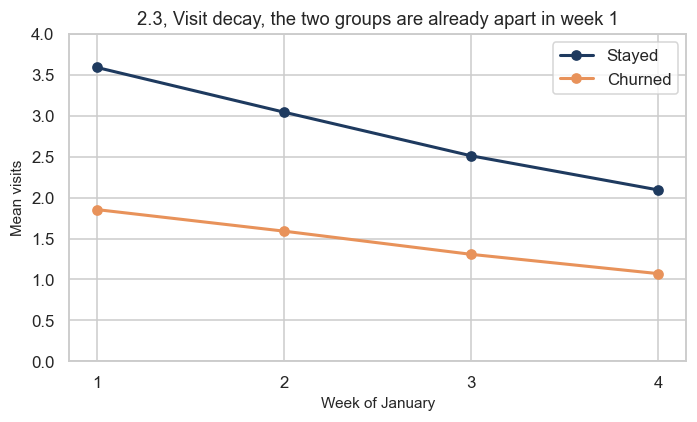

In [10]:
# Build the two derived visit features here since the rest of the EDA leans on them.
# reference: Week 5 slides, "Ratios & Interaction Features" (a ratio carries more signal than the raw counts)
df = raw.copy()
week_cols = [f"week{i}_visits" for i in range(1, 5)]
df["total_visits_m1"] = df[week_cols].sum(axis=1)
df["avg_weekly_visits"] = df["total_visits_m1"] / 4
df["visit_trend"] = df["week4_visits"] - df["week1_visits"]

decay = df.groupby("churned_by_february")[week_cols].mean()
print("Mean visits per week, stayers vs churners:")
print(decay.round(3))
print("\nWeek 4 as a share of week 1:")
print((decay[week_cols[3]] / decay[week_cols[0]]).round(3))

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot([1, 2, 3, 4], decay.loc[0], marker="o", lw=2, color=DARK, label="Stayed")
ax.plot([1, 2, 3, 4], decay.loc[1], marker="o", lw=2, color=ACCENT, label="Churned")
ax.set_xticks([1, 2, 3, 4])
ax.set_xlabel("Week of January")
ax.set_ylabel("Mean visits")
ax.set_ylim(0, 4)
ax.set_title("2.3, Visit decay, the two groups are already apart in week 1")
ax.legend()
plt.tight_layout()
plt.show()

**Observations**

- Both groups decay at the same rate. Stayers 3.59 down to 2.09 (58.3% of week 1), churners 1.85 down to 1.07 (57.8%)
- So the difference is the starting point, not the slope. Churners start at half and never catch up
- Not a "members lose momentum in week 3" problem, a "they showed up half as often on day one" problem
- Anything starting mid month is trying to change a slope thats already identical. And the gap shows in week 1, so risk can be flagged after seven days rather than eight weeks

### 2.4: Churn rate by categorical feature

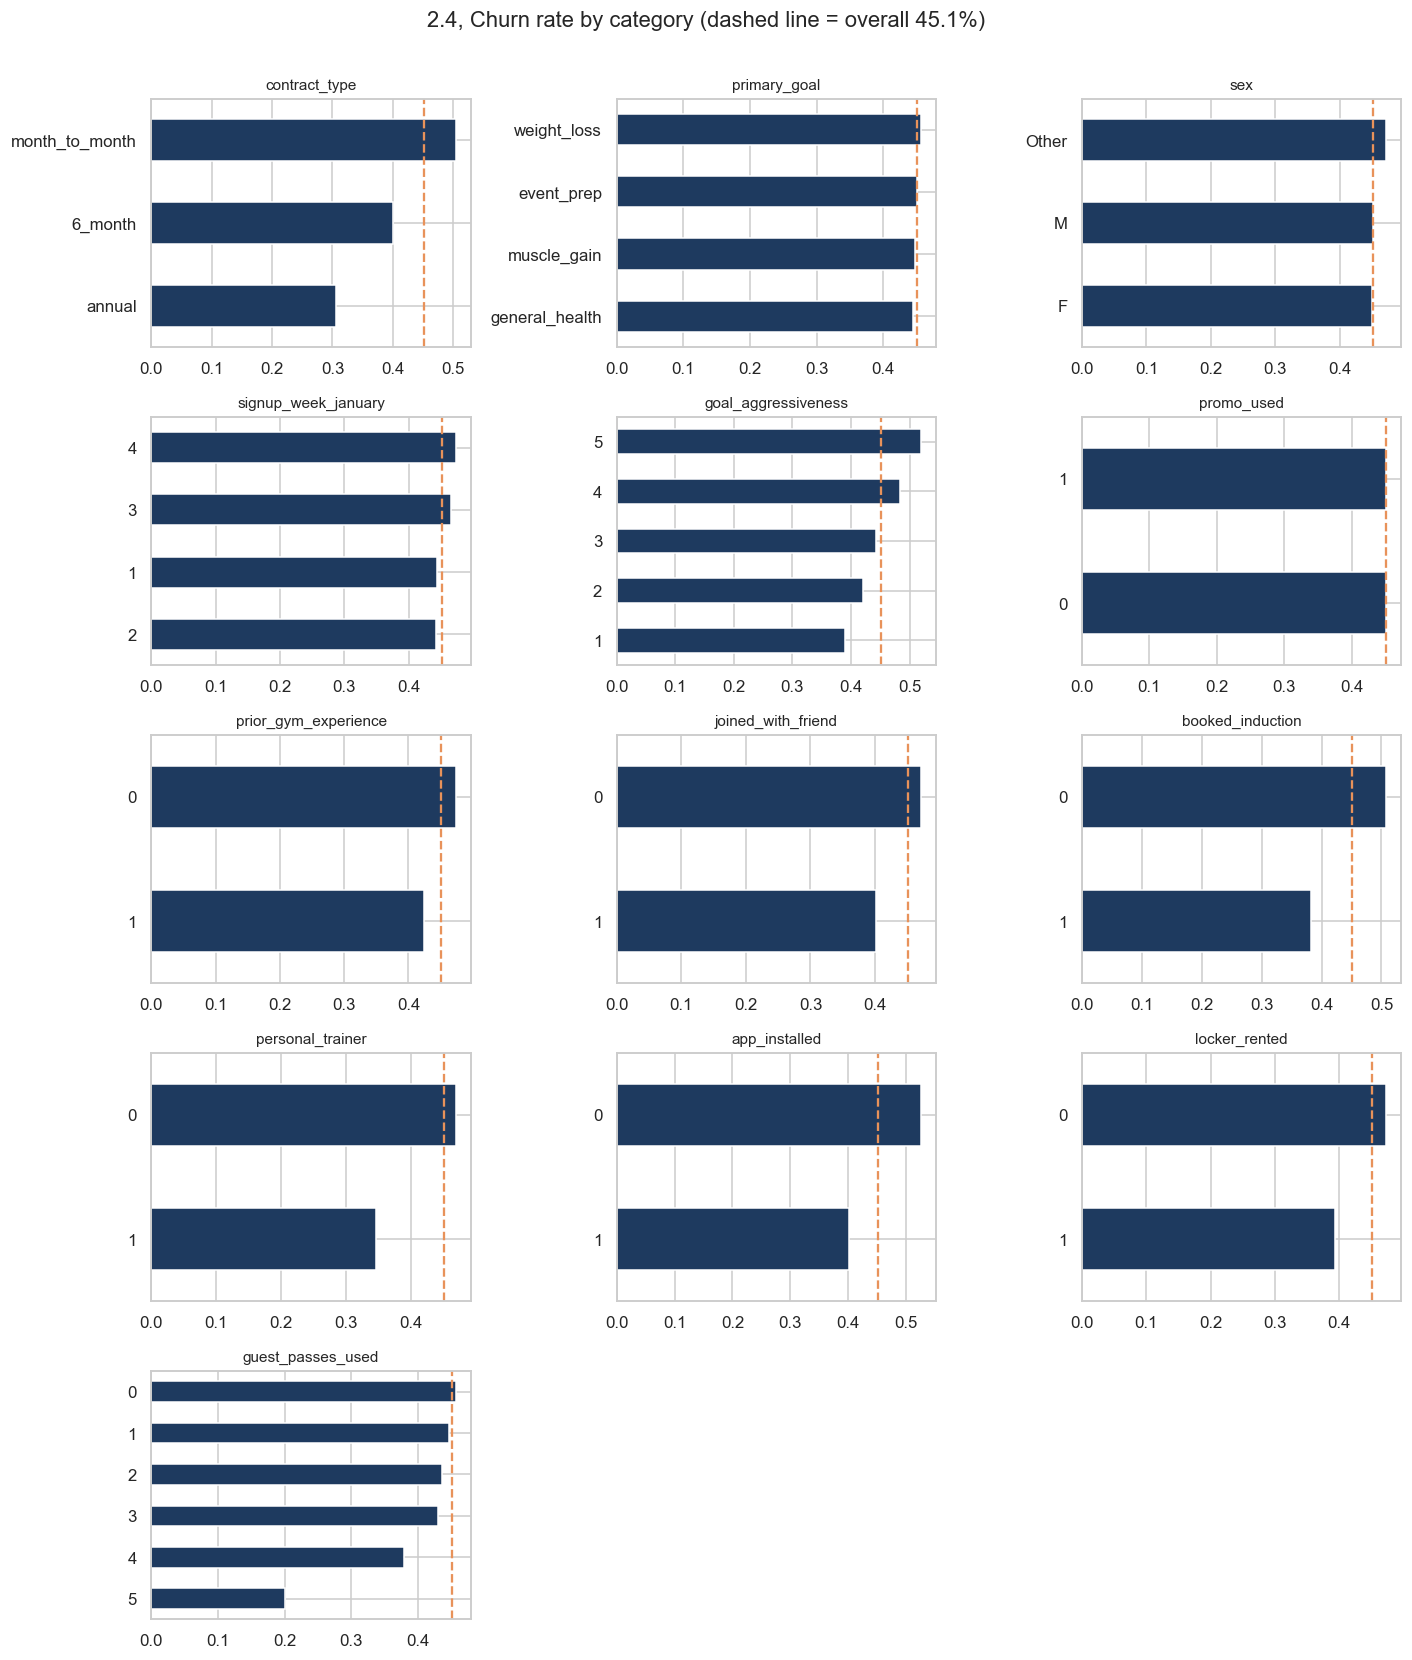


contract_type:
                churn_rate      n
contract_type                    
6_month              0.401  11363
annual               0.306   7417
month_to_month       0.504  31220

goal_aggressiveness:
                     churn_rate      n
goal_aggressiveness                   
1                         0.390  10016
2                         0.420  10065
3                         0.442   9867
4                         0.485  10041
5                         0.519  10011

booked_induction:
                  churn_rate      n
booked_induction                   
0                      0.508  27429
1                      0.382  22571

app_installed:
               churn_rate      n
app_installed                   
0                   0.526  19987
1                   0.402  30013

guest_passes_used:
                   churn_rate      n
guest_passes_used                   
0                       0.456  31133
1                       0.446  14429
2                       0.435   3681
3  

In [11]:
cat_cols = ["contract_type", "primary_goal", "sex", "signup_week_january", "goal_aggressiveness",
            "promo_used", "prior_gym_experience", "joined_with_friend", "booked_induction",
            "personal_trainer", "app_installed", "locker_rented", "guest_passes_used"]

fig, axes = plt.subplots(5, 3, figsize=(13, 15))
for ax in axes.ravel()[len(cat_cols):]:
    ax.axis("off")
for ax, c in zip(axes.ravel(), cat_cols):
    g = df.groupby(c)["churned_by_february"].mean().sort_values()
    g.plot(kind="barh", ax=ax, color=DARK)
    ax.axvline(churn_rate, color=ACCENT, ls="--", lw=1.5)
    ax.set_title(c, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("")
fig.suptitle("2.4, Churn rate by category (dashed line = overall 45.1%)", y=1.005)
plt.tight_layout()
plt.show()

for c in ["contract_type", "goal_aggressiveness", "booked_induction", "app_installed",
          "guest_passes_used"]:
    g = df.groupby(c)["churned_by_february"].agg(["mean", "size"])
    g.columns = ["churn_rate", "n"]
    print(f"\n{c}:")
    print(g.round(3))

**Observations**

- `contract_type` separates most, annual 30.6%, 6_month 40.1%, month_to_month 50.4%. Known at signup
- `goal_aggressiveness` monotonic across all five, 39.0% to 51.9%
- First month flags all separate: induction 38.2% vs 50.8%, app 40.2% vs 52.6%, PT 34.7% vs 46.9%
- Weaker: prior experience 42.4% vs 47.3%, friend 40.1% vs 47.1%, locker 39.3% vs 47.3%. `guest_passes_used` 45.6% down to 43.0% but only 757 used three or more
- `promo_used` is 45.1% either way, which I did not expect. Sex flat, `primary_goal` only 44.4% to 45.6%
- `signup_week_january` 44.4% to 47.3%, small and the opposite way to what I expected

### 2.5: Correlation structure

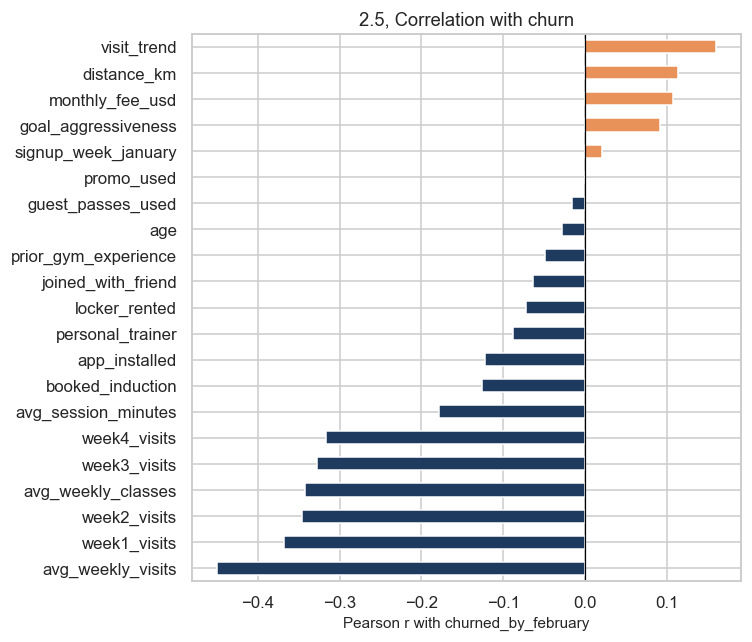

avg_weekly_visits      -0.451
week1_visits           -0.368
week2_visits           -0.346
avg_weekly_classes     -0.343
week3_visits           -0.327
week4_visits           -0.317
avg_session_minutes    -0.178
booked_induction       -0.126
app_installed          -0.122
personal_trainer       -0.088
locker_rented          -0.072
joined_with_friend     -0.063
prior_gym_experience   -0.049
age                    -0.028
guest_passes_used      -0.016
promo_used              0.001
signup_week_january     0.021
goal_aggressiveness     0.092
monthly_fee_usd         0.107
distance_km             0.113
visit_trend             0.161
Name: churned_by_february, dtype: float64


In [12]:
num = df.select_dtypes(include=[np.number]).drop(columns=["total_visits_m1"])
corr_target = num.corr()["churned_by_february"].drop("churned_by_february").sort_values()

fig, ax = plt.subplots(figsize=(7, 6))
colors = [ACCENT if v > 0 else DARK for v in corr_target]
corr_target.plot(kind="barh", ax=ax, color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Pearson r with churned_by_february")
ax.set_title("2.5, Correlation with churn")
plt.tight_layout()
plt.show()

print(corr_target.round(3))

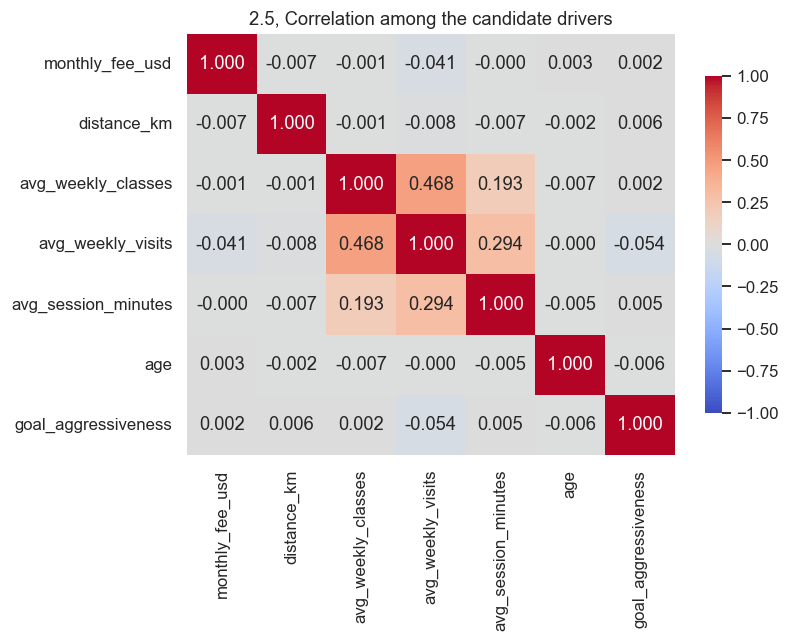

In [13]:
# Do the three candidate levers overlap with each other? 
levers = ["monthly_fee_usd", "distance_km", "avg_weekly_classes", "avg_weekly_visits",
          "avg_session_minutes", "age", "goal_aggressiveness"]
fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(df[levers].corr(), annot=True, fmt=".3f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("2.5, Correlation among the candidate drivers")
plt.tight_layout()
plt.show()

**Observations**

- Top is all behavioural: `avg_weekly_visits` -0.451, `week1_visits` -0.368, `week2_visits` -0.346, `avg_weekly_classes` -0.343, `avg_session_minutes` -0.178
- `visit_trend` +0.161, but only because members who start low have less room to fall
- Then a long way down, `distance_km` +0.113 and `monthly_fee_usd` +0.107. Naively that says A and B beat C by 4x, which is the trap section 3 is about
- The levers barely touch each other, fee vs classes -0.001, vs distance -0.007, vs visits -0.041. So one confounder to worry about, contract type
- Classes vs visits is +0.468 though. A and B arent independent, a class is also a visit

### 2.6: Continuous features split by the target

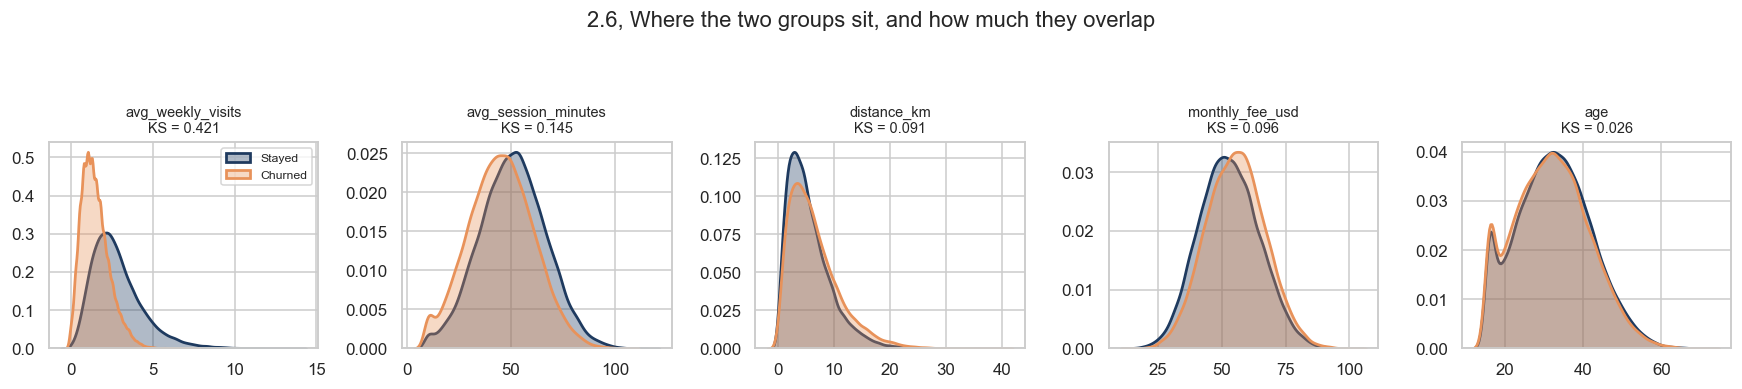

            feature  stayed_median  churned_median   stayed_IQR  churned_IQR    KS
  avg_weekly_visits           2.50            1.25   [1.8, 3.5]   [0.8, 2.0] 0.421
avg_session_minutes          51.00           45.00 [40.0, 61.0] [34.0, 56.0] 0.145
        distance_km           4.70            5.50   [2.7, 7.5]   [3.2, 8.8] 0.091
    monthly_fee_usd          52.39           55.26 [44.5, 60.7] [47.2, 63.0] 0.096
                age          32.00           32.00 [26.0, 39.0] [25.0, 38.0] 0.026


In [14]:
# The correlations in 2.5 are one number per feature. This is the same question drawn out:
# where do the two groups actually sit, and how much do they overlap?
from scipy.stats import ks_2samp

split_cols = ["avg_weekly_visits", "avg_session_minutes", "distance_km", "monthly_fee_usd", "age"]
fig, axes = plt.subplots(1, 5, figsize=(16, 3.2))
for ax, c in zip(axes, split_cols):
    for val, color, lab in [(0, DARK, "Stayed"), (1, ACCENT, "Churned")]:
        sns.kdeplot(df.loc[df["churned_by_february"] == val, c], ax=ax, color=color, fill=True, alpha=0.35, lw=1.8, label=lab)
    ks = ks_2samp(df.loc[df["churned_by_february"] == 1, c], df.loc[df["churned_by_february"] == 0, c]).statistic
    ax.set_title(f"{c}\nKS = {ks:.3f}", fontsize=9.5)
    ax.set_ylabel("")
    ax.set_xlabel("")
axes[0].legend(fontsize=8)
fig.suptitle("2.6, Where the two groups sit, and how much they overlap", y=1.10)
plt.tight_layout()
plt.show()

rows = []
for c in split_cols:
    g = df.groupby("churned_by_february")[c]
    rows.append({
        "feature": c,
        "stayed_median": round(g.median()[0], 2), "churned_median": round(g.median()[1], 2),
        "stayed_IQR": f"[{g.quantile(.25)[0]:.1f}, {g.quantile(.75)[0]:.1f}]",
        "churned_IQR": f"[{g.quantile(.25)[1]:.1f}, {g.quantile(.75)[1]:.1f}]",
        "KS": round(ks_2samp(df.loc[df["churned_by_february"] == 1, c],
                             df.loc[df["churned_by_february"] == 0, c]).statistic, 3),
    })
print(pd.DataFrame(rows).to_string(index=False))

**Observations**

- KS is the biggest gap between the two cumulative distributions, 0 identical and 1 no overlap
- Only `avg_weekly_visits` really separates, KS 0.421, median 2.50 vs 1.25, IQRs [1.8, 3.5] vs [0.8, 2.0]
- `distance_km` 0.091 and `monthly_fee_usd` 0.096 are shifts, not separations. Medians 5.50 vs 4.70 km and $55.26 vs $52.39. The fee curves sit almost on top of each other, which is what Option C has to work with
- `avg_session_minutes` 0.145. `age` flat at 0.026, identical medians of 32
- Nothing cleanly splits this population, so there is a ceiling on any model here before anything is fitted

### 2.7: Fee, contract type and the confounding check

Monthly fee by contract type:
                count   mean  median
contract_type                       
6_month         11363  50.20   50.31
annual           7417  42.01   42.11
month_to_month  31220  58.08   58.09

Churn by fee quintile, raw:
                  mean   size
fee_q                        
(14.999, 43.76]  0.369  10006
(43.76, 50.61]   0.422  10012
(50.61, 56.8]    0.455   9989
(56.8, 63.89]    0.497   9998
(63.89, 101.89]  0.514   9995

Churn by fee quintile WITHIN contract type:
                                churn_rate     n
contract_type  fee_q                            
6_month        (14.999, 43.76]       0.390  2709
               (43.76, 50.61]        0.395  3141
               (50.61, 56.8]         0.400  2856
               (56.8, 63.89]         0.423  1939
               (63.89, 101.89]       0.409   718
annual         (14.999, 43.76]       0.298  4328
               (43.76, 50.61]        0.319  2023
               (50.61, 56.8]         0.316   798
           

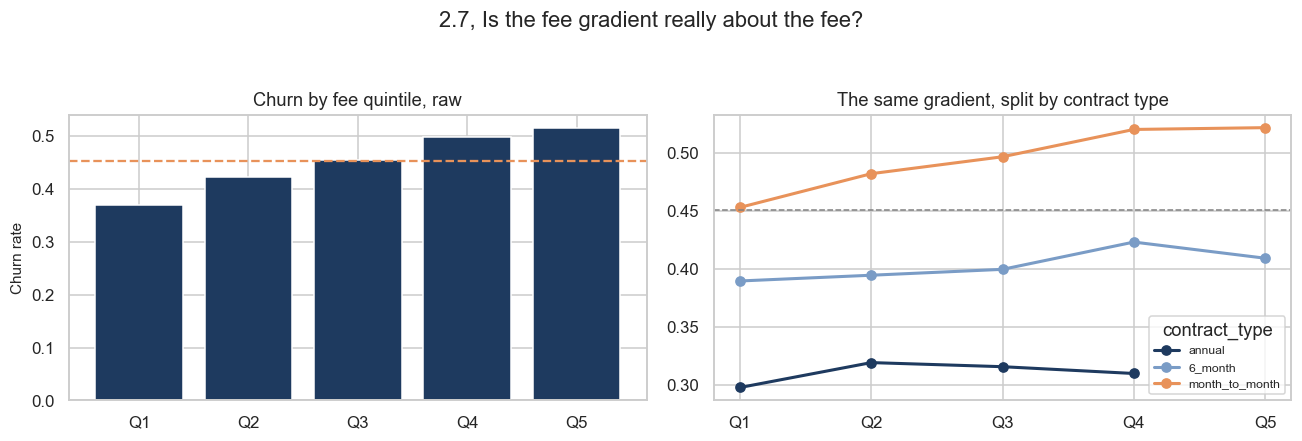

In [15]:
# The client asked specifically whether fee moves with contract type and promotion, so this
# is a descriptive check before any modelling. Pure crosstabs, no model.
df["fee_q"] = pd.qcut(df["monthly_fee_usd"], 5)

print("Monthly fee by contract type:")
print(df.groupby("contract_type")["monthly_fee_usd"].agg(["count", "mean", "median"]).round(2))

print("\nChurn by fee quintile, raw:")
print(df.groupby("fee_q", observed=True)["churned_by_february"].agg(["mean", "size"]).round(3))

print("\nChurn by fee quintile WITHIN contract type:")
within = df.groupby(["contract_type", "fee_q"], observed=True)["churned_by_february"].agg(["mean", "size"])
within.columns = ["churn_rate", "n"]
print(within.round(3))

print("\nPromotion, the other thing the client named:")
print(df.groupby("promo_used")[["monthly_fee_usd", "churned_by_february"]].mean().round(4))
print("promo uptake within contract type:")
print(df.groupby("contract_type")["promo_used"].mean().round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
g = df.groupby("fee_q", observed=True)["churned_by_february"].mean()
axes[0].bar(range(5), g.values, color=DARK)
axes[0].set_xticks(range(5)); axes[0].set_xticklabels([f"Q{i+1}" for i in range(5)])
axes[0].axhline(churn_rate, color=ACCENT, ls="--", lw=1.5)
axes[0].set_title("Churn by fee quintile, raw")
axes[0].set_ylabel("Churn rate")

for ct, color in zip(["annual", "6_month", "month_to_month"], [DARK, "#7a9cc6", ACCENT]):
    sub = within.loc[ct]; sub = sub[sub["n"] >= 100]
    axes[1].plot(range(len(sub)), sub["churn_rate"], marker="o", lw=2, color=color, label=ct)
axes[1].set_xticks(range(5)); axes[1].set_xticklabels([f"Q{i+1}" for i in range(5)])
axes[1].axhline(churn_rate, color="grey", ls="--", lw=1)
axes[1].set_title("The same gradient, split by contract type")
axes[1].legend(title="contract_type", fontsize=8)
fig.suptitle("2.7, Is the fee gradient really about the fee?", y=1.05)
plt.tight_layout()
plt.show()

**Observations**

- Raw fee gradient climbs across quintiles, 36.9%, 42.2%, 45.5%, 49.7%, 51.4%. On its own that reads as "expensive members leave"
- But month to month pays the most ($58.08) and churns the most (50.4%), while annual pays the least ($42.01) and churns the least (30.6%). So a lot of it is really the contract, not the price
- Split inside contract type and most of it goes. 6_month 39.0% to 42.3% and not monotonic, annual 29.8% to 31.9%, month_to_month 45.3% to 52.2%. Something survives but its about half the raw size and it sits in month to month
- Promotion is not a second confounder. Promo users pay $53.88 and non users $53.93, they churn at 45.14% vs 45.09%, and uptake is 54% to 56% in every contract type
- This is the thing the client warned about in their third answer, and it has to be handled properly in Phase 2 rather than left as a crosstab

## 3: Direction for each problem

Both problems get a supervised approach. The reasoning differs between them, so I set out each one separately.

### 3.1: Problem 1 (Phase 1), which option does the data support?

**Direction:** supervised, and explanatory rather than predictive

**Reasoning:**

`churned_by_february` exists for all 50,000 members and its exactly what leadership cares about, so unsupervised is out. Clustering would just give me groups defined by whatever dominates the scaled feature space and Id have to check each one against the churn label anyway, which is a longer road to the same place. Within supervised theres still a choice between explanatory and predictive, and this problem asks which of three interventions the data supports rather than what a given member does next. Thats a question about mechanism, so I use group churn rates, effect sizes and a permutation test, and leave the classifier for Problem 2. One thing I add that the brief doesnt mention is that a correlation is only a lever if the gym can move it, so I also score each option on whether its known before the member behaves and whether the gym can change it at all. The EDA already hints thats what separates the three, since classes and visits are measured inside the churn window while the fee is set at signup.

### 3.2: Problem 2 (Phase 2), how much does the fee drive churn?

**Direction:** supervised classification, logistic regression as the primary model

**Reasoning:**

The target is labelled and binary so this is a classifier and not a regressor, and unsupervised is out for the same reason as Problem 1. The real choice is logistic regression against a tree ensemble and I go with logistic, because the client needs two different things out of one model. The coefficients convert to odds ratios reading as each extra dollar multiplying the odds of churning by some amount, which is what prices a decision, while a forest only gives a feature ranking that cant say what a $10 change does. The client also confirmed the model has to be something management can follow, which settles it, and Ill fit a forest and a booster anyway as a check. The objective is retained revenue rather than churn, since minimising churn on its own is degenerate when the cheapest way to hit it is giving memberships away. Isolating the fee is then a matter of nested models, watching the coefficient move as contract type and the signup controls go in, which 2.7 shows is necessary. Metrics are precision, recall, F1 and AUC with the threshold tuned rather than left at 0.5, since a false negative is a lost membership and a false positive is one email.